In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [74]:
dataset = pd.read_csv("Salary_Data.csv")

In [75]:
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X = dataset.iloc[:, :-1].values     
y = dataset.iloc[:, -1].values

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
y_pred = model.predict(X_test)

In [82]:
comparison = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

In [83]:
print(comparison)


   Actual Salary  Predicted Salary
0        37731.0      41056.257055
1       122391.0     123597.709384
2        57081.0      65443.504334
3        63218.0      63567.562235
4       116969.0     116093.940990
5       109431.0     108590.172597
6       112635.0     117031.912039
7        55794.0      64505.533285


In [84]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)


Mean Absolute Error: 3508.5455930660555


In [85]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 22407940.143340684


In [86]:
score = model.score(X_test, y_test)

print("Model Score:", score)
print("Model Score (%):", score * 100)

Model Score: 0.9779208335417602
Model Score (%): 97.79208335417601


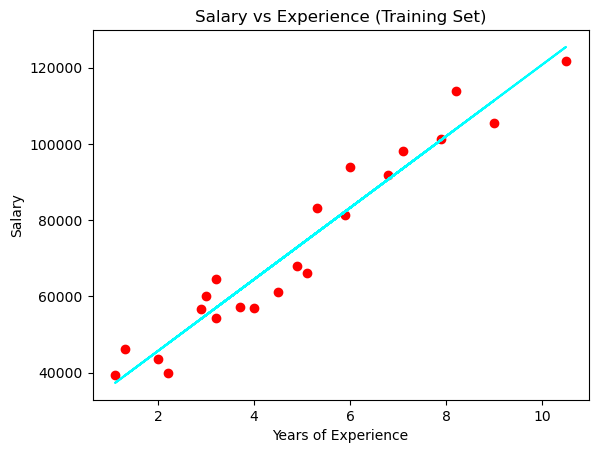

In [87]:

plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, model.predict(X_train), '-', color='cyan')

plt.title("Salary vs Experience (Training Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [89]:
mean_absolute_error(y_test, y_pred)

3508.5455930660555

In [90]:
r2_score(y_test, y_pred)

0.9779208335417602

In [91]:
# Simple cross-validation (5-fold) for Linear Regression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model_cv = LinearRegression()
cv_scores = cross_val_score(model_cv, X, y, cv=5, scoring='r2')
print('CV R2 scores:', cv_scores)
print('Mean CV R2: {:.4f}'.format(cv_scores.mean()))

CV R2 scores: [ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]
Mean CV R2: -0.0534


In [92]:
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [93]:
# Creating Polynomial Features

In [94]:
from sklearn.preprocessing import PolynomialFeatures

In [95]:
poly = PolynomialFeatures(degree=3)

In [96]:
x_poly = poly.fit_transform(X)

In [97]:
x_poly

array([[1.000000e+00, 1.100000e+00, 1.210000e+00, 1.331000e+00],
       [1.000000e+00, 1.300000e+00, 1.690000e+00, 2.197000e+00],
       [1.000000e+00, 1.500000e+00, 2.250000e+00, 3.375000e+00],
       [1.000000e+00, 2.000000e+00, 4.000000e+00, 8.000000e+00],
       [1.000000e+00, 2.200000e+00, 4.840000e+00, 1.064800e+01],
       [1.000000e+00, 2.900000e+00, 8.410000e+00, 2.438900e+01],
       [1.000000e+00, 3.000000e+00, 9.000000e+00, 2.700000e+01],
       [1.000000e+00, 3.200000e+00, 1.024000e+01, 3.276800e+01],
       [1.000000e+00, 3.200000e+00, 1.024000e+01, 3.276800e+01],
       [1.000000e+00, 3.700000e+00, 1.369000e+01, 5.065300e+01],
       [1.000000e+00, 3.900000e+00, 1.521000e+01, 5.931900e+01],
       [1.000000e+00, 4.000000e+00, 1.600000e+01, 6.400000e+01],
       [1.000000e+00, 4.000000e+00, 1.600000e+01, 6.400000e+01],
       [1.000000e+00, 4.100000e+00, 1.681000e+01, 6.892100e+01],
       [1.000000e+00, 4.500000e+00, 2.025000e+01, 9.112500e+01],
       [1.000000e+00, 4.9

In [ ]:
# Fit Polynomial Regression on training data and evaluate on test set
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

print('R2 score (Polynomial Regression):', r2_score(y_test, y_pred_poly))

NameError: name 'code' is not defined

In [ ]:
# Cross-validation (5-fold) for Polynomial Regression using a pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([('poly', PolynomialFeatures(degree=3)), ('lr', LinearRegression())])
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print('Cross-validation R2 scores:', cv_scores)
print('CV R2 mean: {:.4f} (+/- {:.4f})'.format(cv_scores.mean(), cv_scores.std()))

In [ ]:
# Linear Regression baseline R2 on the test set (existing linear model)
print('R2 score (Linear Regression):', r2_score(y_test, y_pred))

In [ ]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
poly_model = LinearRegression()

In [ ]:
poly_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred_poly = poly_model.predict(X_test_poly)

In [ ]:
#r2
r2_score(y_test, y_pred_poly)

0.9820791019770558

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model_cv = LinearRegression()
cv_scores = cross_val_score(model_cv, X, y, cv=5, scoring='r2')
print('CV R2 scores:', cv_scores)
print('Mean CV R2: {:.4f}'.format(cv_scores.mean()))

CV R2 scores: [ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]
Mean CV R2: -0.0534


In [ ]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    x_poly,
    y,
    test_size=0.25,
    random_state=0
)
lr = LinearRegression()
lr.fit(X_poly_train, y_poly_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = lr.predict(X_poly_test)

In [ ]:
y_pred

array([ 43180.78619154, 119716.69420781,  63506.12145538,  61487.51703951,
       116204.44477376, 110842.07859796, 116752.59076765,  62490.48706816])

In [ ]:
r2_score(y_poly_test, y_pred)

0.9820791019770558

In [102]:
# overfitting check
train_r2 = lr.score(X_poly_train, y_poly_train)
test_r2 = lr.score(X_poly_test, y_poly_test)
print('Train R2:', train_r2)
print('Test R2:', test_r2)
print('Train-Test gap:', train_r2 - test_r2)

if train_r2 - test_r2 > 0.1:
    print('Possible overfitting: train score is notably higher than test score.')
else:
    print('No strong overfitting signal detected.')

NameError: name 'X_poly_train' is not defined